# Configuración del entorno

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold

# Carga e inspección estructural del dataset

In [3]:
df = pd.read_csv('./house-prices-tp.csv', sep=',', encoding='latin-1')

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [6]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Dimensiones del dataset: 556 filas x 14 columnas
Memoria utilizada: 0.06 MB


In [7]:
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (14): ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Variables categoricas (0): []


### Sobre el dataset house_prices_tp

El dataset contiene 556 filas con información de precios de casas de Boston, ademas de las siguientes variables:

| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `CRIM` | Continua Razón | tasa de criminalidad per cápita |
| `ZN` | Continua Razón | proporción de terrenos residenciales zonificados para lotes de más de 25.000 pies cuadrados |
| `INDUS` | Continua Razón | proporción de acres de negocios no minoristas por ciudad |
| `CHAS` | Categórica nominal dicotómica | variable dummy del río Charles (1 si el tramo limita con el río, 0 de lo contrario) |
| `NOX` | Continua Razón | concentración de óxidos de nitrógeno (partes por 10 millones) |
| `RM` | Continua Razon | número promedio de habitaciones por vivienda |
| `AGE` | Continua Razón | proporción de unidades ocupadas por sus propietarios construidas antes de 1940 |
| `DIS` | Continua Razón | distancias ponderadas a cinco centros de empleo de Boston |
| `RAD` | Ordinal | índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | tasa de immpuesto sobre la propiedad a valor completo por $10000 |
| `PTRATIO` | Continua Razon | proporción alumno-maestro por ciudad |
| `B` | Continua Razon | el resultado de la ecuación B=1000(Bk - 0.63)^2 donde Bk es la proporción de negros por ciudad |
| `LSTAT` | Continua Razon | % de población de menor estatus socioeconómico |
| `MEDV` | Continua Razón | valor mediano de las viviendas ocupadas por sus propietarios en miles de dolares |

# Análisis descriptivo
## Medidas de tendencia centraly dispersión

In [8]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.845517,0.315330,13.828631,236.568126,0.00632,0.08447,0.315330,4.871410,88.9762,3.746677,15.248736
ZN,13.197175,0.000000,24.902981,188.699327,0.00000,0.00000,0.000000,20.000000,100.0000,1.957797,2.749832
INDUS,11.218725,9.690000,6.942021,61.878878,0.46000,5.13000,9.690000,18.100000,27.7400,0.301523,-1.206425
CHAS,0.090056,0.000000,0.286531,318.169129,0.00000,0.00000,0.000000,0.000000,1.0000,2.872201,6.273064
NOX,0.560050,0.538000,0.119472,21.332472,0.38500,0.45300,0.538000,0.643986,0.8710,0.694358,-0.229572
RM,6.291839,6.208000,0.782403,12.435196,3.56100,5.87550,6.208000,6.638500,8.7800,0.373812,1.555062
AGE,67.632303,76.500000,28.461925,42.083330,2.90000,42.27500,76.500000,93.825000,100.0000,-0.550692,-1.038192
DIS,3.944102,3.340107,2.255689,57.191447,1.12960,2.11210,3.340107,5.400700,12.1265,1.078906,0.705364
RAD,9.699379,5.000000,8.684495,89.536607,1.00000,4.00000,5.000000,23.632660,24.0000,0.951478,-0.947840
TAX,409.575089,335.000000,167.689379,40.942280,187.00000,279.00000,335.000000,666.000000,711.0000,0.632306,-1.170504


In [9]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
      CRIM: sesgo=+3.747 [sesgo positivo (alto)], curtosis=+15.249 [leptocurtica (colas pesadas)]
        ZN: sesgo=+1.958 [sesgo positivo (alto)], curtosis=+2.750 [leptocurtica (colas pesadas)]
     INDUS: sesgo=+0.302 [aproximadamente simetrica], curtosis=-1.206 [platicurtica (colas livianas)]
      CHAS: sesgo=+2.872 [sesgo positivo (alto)], curtosis=+6.273 [leptocurtica (colas pesadas)]
       NOX: sesgo=+0.694 [sesgo positivo (moderado)], curtosis=-0.230 [mesocurtica]
        RM: sesgo=+0.374 [aproximadamente simetrica], curtosis=+1.555 [leptocurtica (colas pesadas)]
       AGE: sesgo=-0.551 [sesgo negativo (moderado)], curtosis=-1.038 [platicurtica (colas livianas)]
       DIS: sesgo=+1.079 [sesgo positivo (alto)], curtosis=+0.705 [leptocurtica (colas pesadas)]
       RAD: sesgo=+0.951 [sesgo positivo (moderado)], curtosis=-0.948 [platicurtica (colas livianas)]
       TAX: sesgo=+0.632 [sesgo positivo (moderado)], curtosis=-1.171 [platicurtica

(array([ 4.,  7., 11., 14., 15., 32., 30., 23., 34., 52., 51., 51., 53.,
        23., 11., 19., 15., 11., 16.,  6., 10.,  6.,  3.,  2.,  3.,  4.,
         4.,  4.,  1., 20.]),
 array([ 5. ,  6.5,  8. ,  9.5, 11. , 12.5, 14. , 15.5, 17. , 18.5, 20. ,
        21.5, 23. , 24.5, 26. , 27.5, 29. , 30.5, 32. , 33.5, 35. , 36.5,
        38. , 39.5, 41. , 42.5, 44. , 45.5, 47. , 48.5, 50. ]),
 <BarContainer object of 30 artists>)

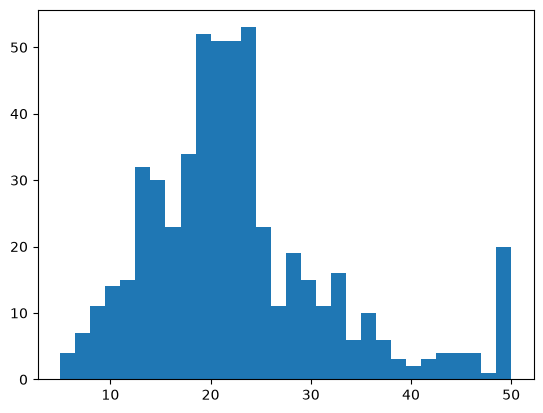

In [10]:
plt.hist(df["MEDV"], bins=30)

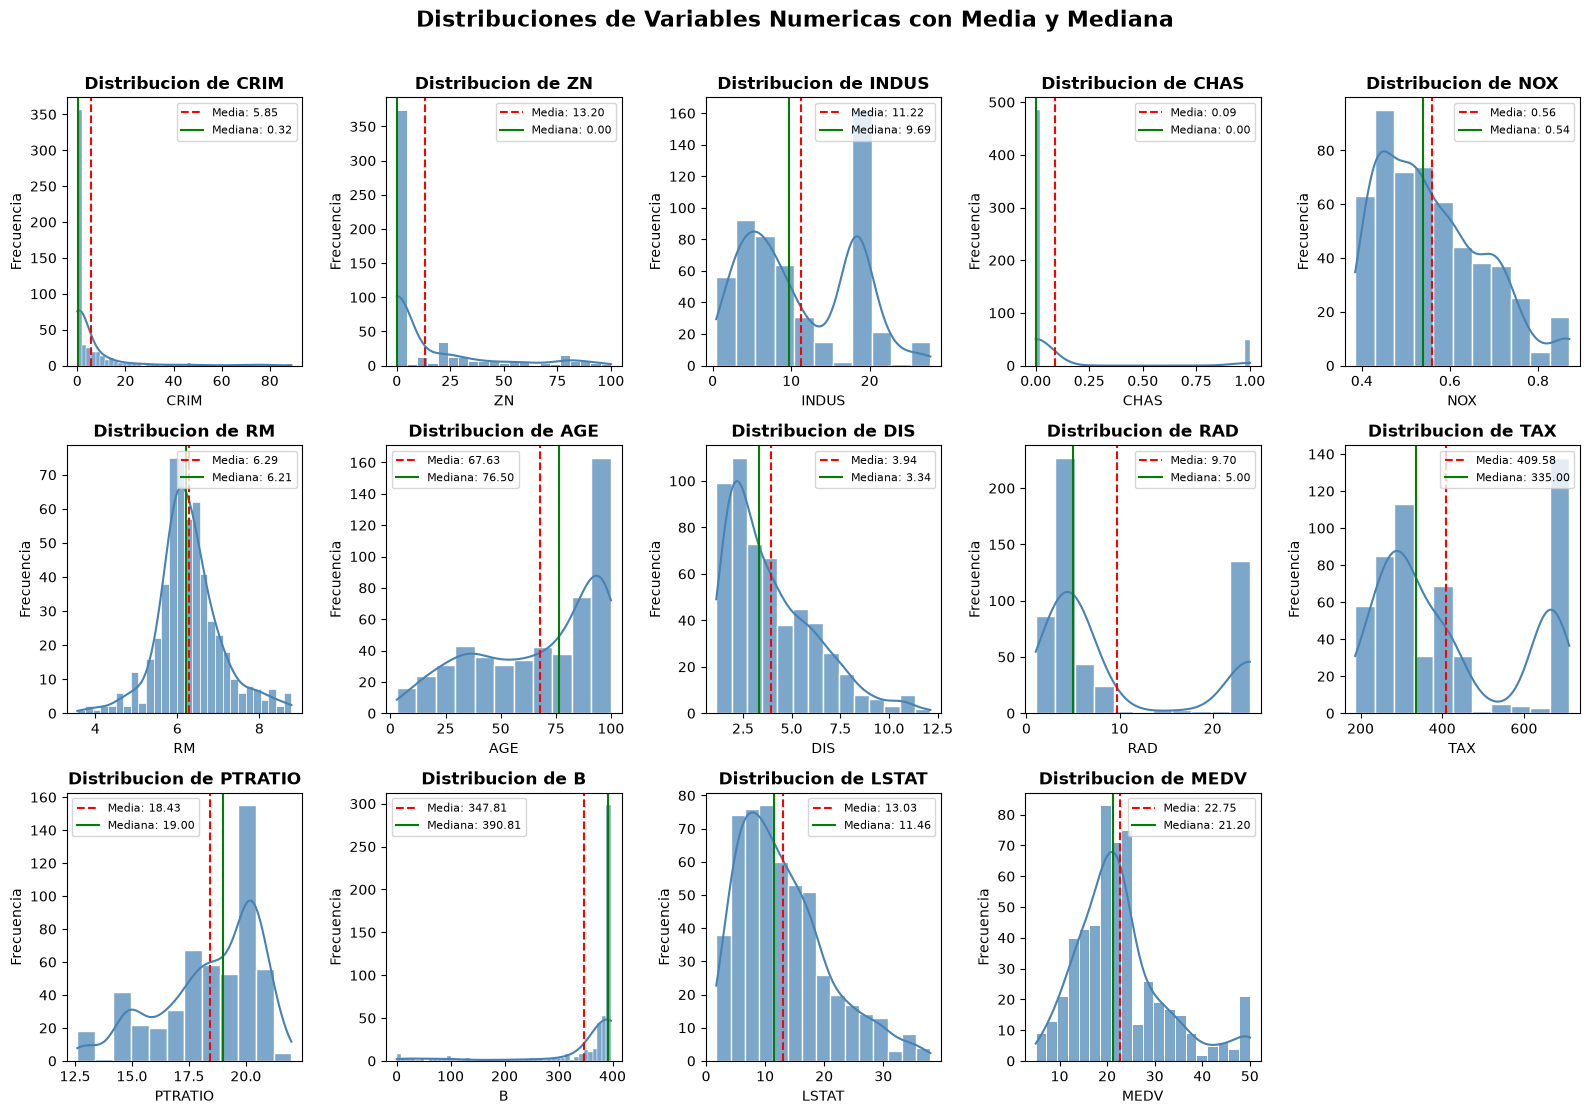

In [11]:
fig, axes = plt.subplots(4, 5, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

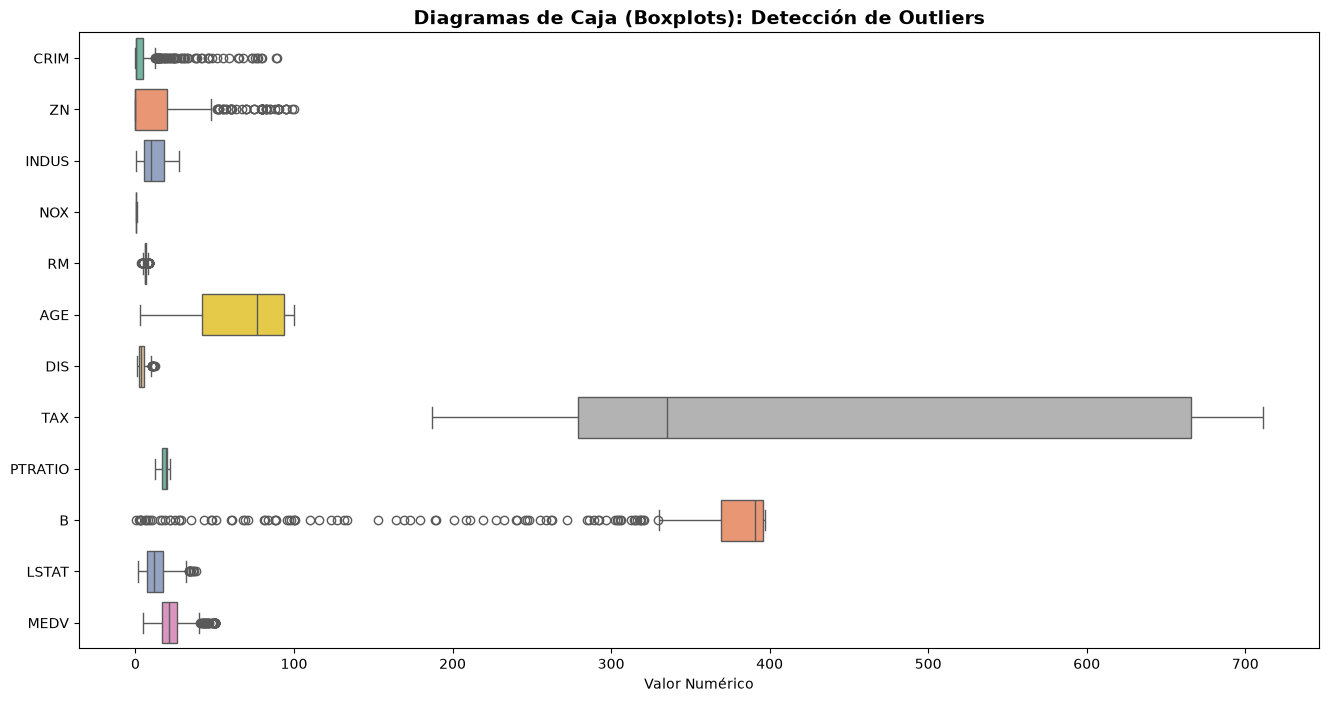

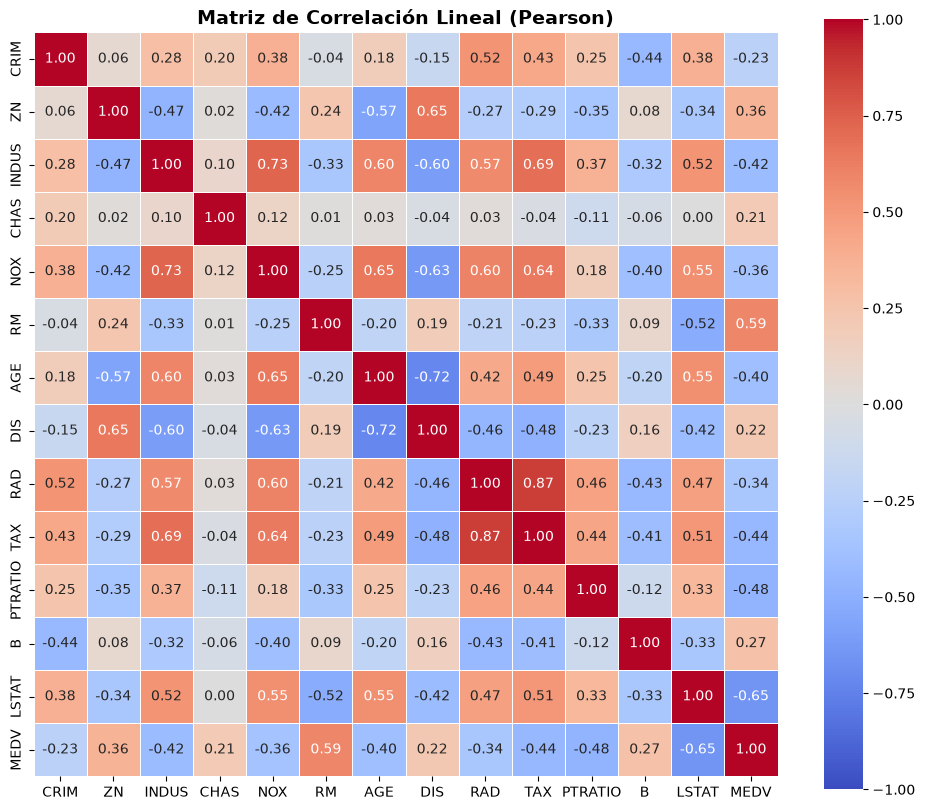

In [12]:
# 1. Diagramas de Caja (Boxplots) para detectar valores atípicos
plt.figure(figsize=(16, 8))
# Excluimos CHAS (dummy) y RAD (ordinal discreta) porque el boxplot no les aporta valor
sns.boxplot(data=df.drop(columns=['CHAS', 'RAD']), orient="h", palette="Set2")
plt.title('Diagramas de Caja (Boxplots): Detección de Outliers', fontweight='bold', fontsize=14)
plt.xlabel('Valor Numérico')
plt.show()

# 2. Matriz de Correlación de Pearson
plt.figure(figsize=(12, 10))
matriz_corr = df.corr(method='pearson')
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Matriz de Correlación Lineal (Pearson)', fontweight='bold', fontsize=14)
plt.show()

Desproporción extrema (ej. TAX > 700 vs NOX < 1). Hace obligatorio el escalado de datos previo al entrenamiento para evitar sesgar en algoritmo.  

Valores atípicos extremos en CRIM, ZN, B y MEDV. Afectan negativamente el ajuste de los modelos lineales y exigen métodos de escalado robustos o transformaciones.  
Predictores clave: Mayor poder predictivo sobre MEDV: LSTAT (-0.65, correlación inversa) y RM (0.59, correlación directa).

Multicolinealidad : RAD y TAX presentan una altísima correlación lineal positiva (0.87). Evaluar reducción de dimensionalidad o eliminar una de las variables!!

# Gestión de datos nulos, duplicados y consistencia

In [13]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23        4.136691  float64
ZN          22        3.956835  float64
INDUS       15        2.697842  float64
CHAS        23        4.136691  float64
NOX         24        4.316547  float64
RM          21        3.776978  float64
AGE         24        4.316547  float64
DIS         15        2.697842  float64
RAD         28        5.035971  float64
TAX         18        3.237410  float64
PTRATIO     28        5.035971  float64
B           22        3.956835  float64
LSTAT       22        3.956835  float64
MEDV        21        3.776978  float64

Total de celdas con nulos: 306 (3.9311% del dataset)


In [14]:
na = df.isna().any(axis=1)
print(f'Filas con datos nulos: {na.sum()}')
print(f'Porcentaje de filas con datos nulos: {na.sum() / df.shape[0] * 100:.2f}%')

Filas con datos nulos: 50
Porcentaje de filas con datos nulos: 8.99%


El dataset cuenta con 556 filas de las cuales 50 tienen datos nulos, los cuales representan ~9% del dataset.

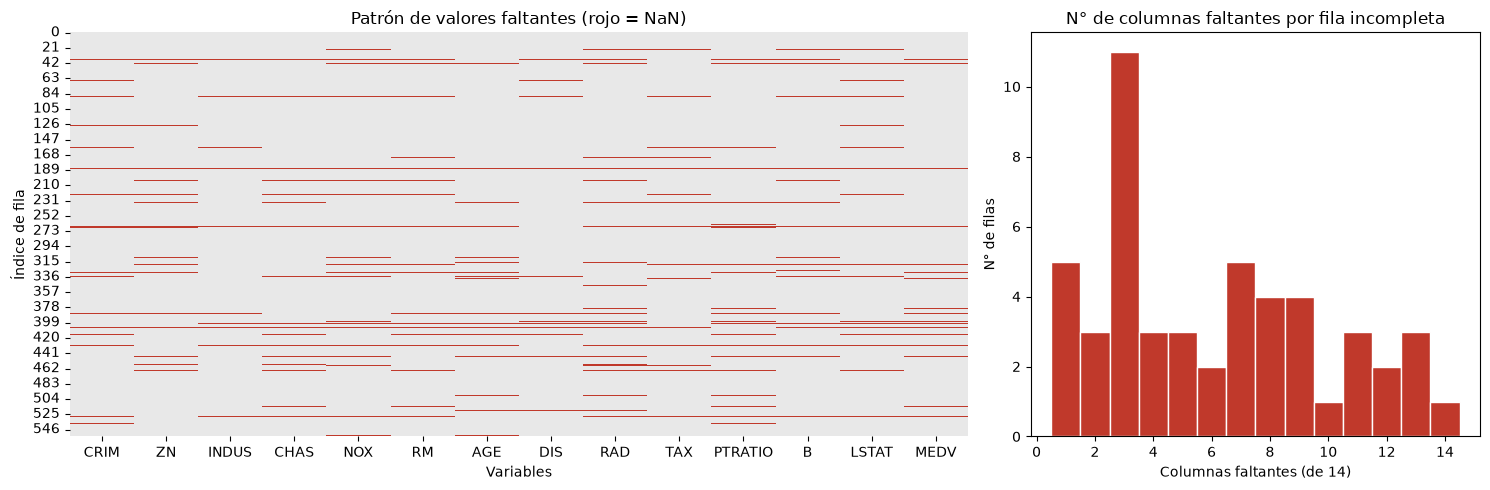

In [15]:
mask_na = df.isna()
filas_con_na = mask_na.any(axis=1)

faltantes_por_fila = mask_na.sum(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

# Izquierda: mapa de la tabla completa. Cada franja roja horizontal es una fila incompleta.
sns.heatmap(mask_na, cbar=False, cmap=['#e8e8e8', '#c0392b'], ax=ax[0])
ax[0].set_title('Patrón de valores faltantes (rojo = NaN)')
ax[0].set_xlabel('Variables'); ax[0].set_ylabel('Índice de fila')

# Derecha: cuántas columnas le faltan a cada fila incompleta
ax[1].hist(faltantes_por_fila[filas_con_na], bins=np.arange(0.5, 15.5, 1),
           color='#c0392b', edgecolor='white')
ax[1].set_title('N° de columnas faltantes por fila incompleta')
ax[1].set_xlabel('Columnas faltantes (de 14)'); ax[1].set_ylabel('N° de filas')

plt.tight_layout(); plt.show()

Hay 1 fila que esta completamente vacía (14 columnas nulas), 9 filas con entre 10 y 13 datos faltantes, 21 filas con entre 4 y 9 valores faltantes, 11 filas con 3 datos faltantes y 8 filas con entre 1 y 2 datos faltantes.
Decidimos:
- Eliminar la fila con valores completamente nulos
- Eliminar las filas donde la variable target (MEDV) esta vacia
- Eliminar las filas donde no contemos con datos en las columnas RM, TAX, LSTAT, DIS

In [16]:
df_limpio = df.copy()
filas_init = len(df_limpio)

mask_vacias = df_limpio.isna().all(axis=1)
df_limpio = df_limpio[~mask_vacias]

print(f'Filas eliminadas por estar completamente vacías: {filas_init - len(df_limpio)}')

Filas eliminadas por estar completamente vacías: 1


In [17]:
mask_sin_target = df_limpio['MEDV'].isna()
df_limpio = df_limpio[~mask_sin_target]

print(f'Filas eliminadas por no tener valor en la variable objetivo (MEDV): {filas_init - len(df_limpio)}')

Filas eliminadas por no tener valor en la variable objetivo (MEDV): 21


In [20]:
cols_importantes = ['RM', 'TAX', 'LSTAT', 'DIS']
mask_importantes = df_limpio[cols_importantes].isna().any(axis=1)
df_limpio = df_limpio[~mask_importantes]

print(f'Filas eliminadas por no tener valor en alguna de las variables importantes {cols_importantes}: {filas_init - len(df_limpio)}')

Filas eliminadas por no tener valor en alguna de las variables importantes ['RM', 'TAX', 'LSTAT', 'DIS']: 38


In [23]:
df_limpio = df_limpio.reset_index(drop=True)

print(f'Filas iniciales: {filas_init}')
print(f'Filas finales:   {len(df_limpio)}')
print(f'Filas eliminadas: {filas_init - len(df_limpio)} '
      f'({(filas_init - len(df_limpio)) / filas_init * 100:.2f}% del dataset)')

Filas iniciales: 556
Filas finales:   518
Filas eliminadas: 38 (6.83% del dataset)


In [24]:
nulos_restantes = df_limpio.isna().sum()
print('Nulos remanentes por columna:')
print(nulos_restantes[nulos_restantes > 0])
print(f'\nFilas con al menos un nulo: {df_limpio.isna().any(axis=1).sum()}')

Nulos remanentes por columna:
CRIM       3
ZN         5
CHAS       2
NOX        2
AGE        6
RAD        4
PTRATIO    4
B          3
dtype: int64

Filas con al menos un nulo: 12


# Train - Test Split

Generamos un split en el dataset para obtener los datos de entrenamiento (80%) y los de prueba (20%)

In [ ]:
x = df_limpio.drop(columns=['MEDV'])
y = df_limpio['MEDV']